In [11]:
import pandas as pd
import numpy as np
data = pd.read_csv('https://raw.githubusercontent.com/npradaschnor/Pima-Indians-Diabetes-Dataset/master/diabetes.csv')

In [2]:
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
data.shape

(768, 9)

In [4]:
X = data.drop('Outcome', axis=1)
y = data['Outcome']

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [6]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

In [7]:
y_scores = model.predict_proba(X_test)[:,1]

In [8]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test,y_scores)

In [9]:
thresholds

array([       inf, 0.99355937, 0.95264728, 0.95245836, 0.82469944,
       0.76882392, 0.76200245, 0.68387286, 0.67531753, 0.6742218 ,
       0.65117348, 0.65085241, 0.63549862, 0.58629936, 0.57564401,
       0.56975015, 0.52517323, 0.47018983, 0.46129946, 0.45043959,
       0.4390252 , 0.43865295, 0.4222991 , 0.41991158, 0.41302816,
       0.41197927, 0.40477566, 0.37970757, 0.36866493, 0.3102008 ,
       0.30880229, 0.2777265 , 0.27204126, 0.25510189, 0.25508922,
       0.24741262, 0.24547551, 0.23663771, 0.22887574, 0.18185097,
       0.17861303, 0.17458364, 0.17326451, 0.14638062, 0.14076004,
       0.1167129 , 0.11494149, 0.11000696, 0.10666739, 0.08923238,
       0.08672187, 0.02001588, 0.01931344, 0.00160777])

In [13]:
optimal_index = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_index]
print(optimal_threshold)

0.3686649253145685


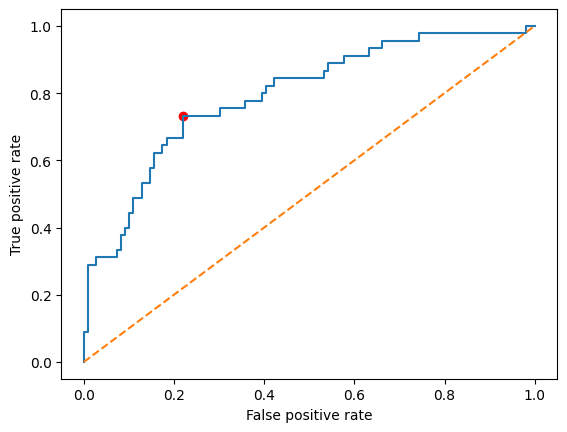

In [49]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_scores)

roc_curve = auc(fpr,tpr)

plt.figure()
plt.plot(fpr, tpr, label=f'AUC Curve {roc_curve:2f}')
plt.scatter(fpr[optimal_index],tpr[optimal_index], label='Optimal',color='red')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.show()